# SOBRE PARQUET

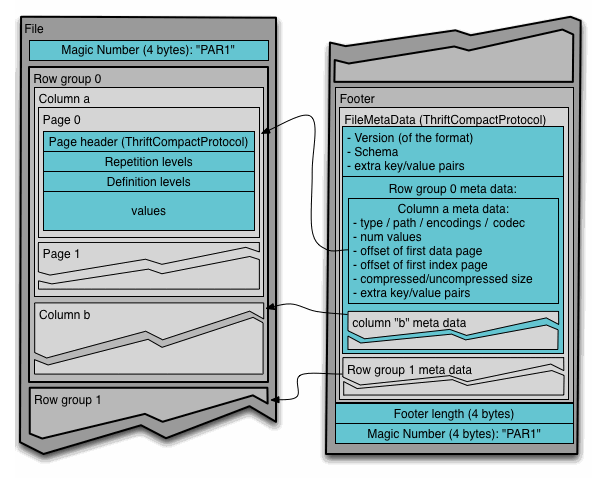

In [1]:
from pyspark.sql import SparkSession
import pyarrow.parquet as pq
import os

# Configuración de Spark con soporte para Arrow
spark = SparkSession.builder \
    .appName("MetadatosParquet") \
    .config("spark.sql.execution.arrow.pyspark.enabled", "true") \
    .getOrCreate()

In [2]:
# Ruta de tu carpeta de parquets
ruta_parquets = "/data/parquets/"

# Listamos los archivos y tomamos el primero que sea .parquet para inspeccionarlo
archivos = [f for f in os.listdir(ruta_parquets) if f.endswith('.parquet')]
archivo_ejemplo = os.path.join(ruta_parquets, archivos[0])

# LEER METADATOS CON PYARROW
meta = pq.read_metadata(archivo_ejemplo)

print("--- METADATOS TÉCNICOS (PYARROW) ---")
print(f"Creado por: {meta.created_by}")
print(f"Formato Parquet versión: {meta.format_version}")
print(f"Número de columnas: {meta.num_columns}")
print(f"Número de Row Groups: {meta.num_row_groups}")
print(f"Esquema desde PyArrow:\n{meta.schema}")

--- METADATOS TÉCNICOS (PYARROW) ---
Creado por: parquet-mr version 1.13.1 (build db4183109d5b734ec5930d870cdae161e408ddba)
Formato Parquet versión: 1.0
Número de columnas: 5
Número de Row Groups: 1
Esquema desde PyArrow:
required group field_id=-1 spark_schema {
  optional int64 field_id=-1 id_venta;
  optional int32 field_id=-1 fecha (Date);
  optional int32 field_id=-1 id_producto;
  optional int32 field_id=-1 cantidad;
  optional double field_id=-1 total_venta;
}



In [3]:
# LEER CON SPARK (usando la optimización de Arrow por debajo)
df_spark = spark.read.parquet(ruta_parquets)

print("\n--- ESQUEMA DE ALTO NIVEL (SPARK) ---")
df_spark.printSchema()

print(f"Conteo total de registros: {df_spark.count()}")

# Mostrar datos (Arrow acelera esta visualización)
df_spark.show(5)


--- ESQUEMA DE ALTO NIVEL (SPARK) ---
root
 |-- id_venta: long (nullable = true)
 |-- fecha: date (nullable = true)
 |-- id_producto: integer (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- total_venta: double (nullable = true)

Conteo total de registros: 100000
+--------+----------+-----------+--------+-----------+
|id_venta|     fecha|id_producto|cantidad|total_venta|
+--------+----------+-----------+--------+-----------+
|       1|2026-01-05|          4|       2|       10.0|
|       2|2026-01-31|          1|      10|      155.0|
|       3|2026-02-02|          1|       5|       77.5|
|       4|2026-01-11|          3|       9|      98.91|
|       5|2026-01-21|          5|       9|      900.0|
+--------+----------+-----------+--------+-----------+
only showing top 5 rows



In [7]:
print(meta)

  created_by: parquet-mr version 1.13.1 (build db4183109d5b734ec5930d870cdae161e408ddba)
  num_columns: 5
  num_rows: 100000
  num_row_groups: 1
  format_version: 1.0
  serialized_size: 1210


In [ ]:
spark.stop()